In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow
from tensorflow import keras
from keras.datasets import mnist
from keras.layers import Dense, Flatten, Dropout
from keras import Sequential
from tensorflow.math import confusion_matrix
import os

In [6]:
tensorflow.random.set_seed(42)
np.random.seed(42)

In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

In [8]:
print(f"Number of images in the training dataset: {x_train.shape[0]}")
print(f"Number of images in the testing dataset: {x_test.shape[0]}")

Number of images in the training dataset: 60000
Number of images in the testing dataset: 10000


In [9]:
print(f"Shape of the image in the training dataset: {x_train[0].shape}")

Shape of the image in the training dataset: (28, 28)


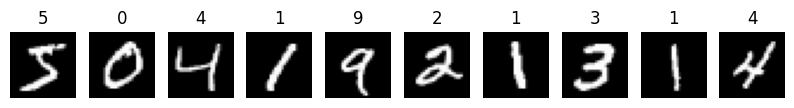

In [10]:
fig, axes = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axes[i].imshow(x_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(y_train[i])
    axes[i].axis('off')
plt.show()

# Model 1 :

In [78]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax'),
])

c:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [79]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
model.fit(x_train, y_train, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9318 - loss: 0.2329
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9695 - loss: 0.1005
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9797 - loss: 0.0677


In [82]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,848 (1.35 MB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 236,566 (924.09 KB)

In [83]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Accuracy of the neural network on the {x_test.shape[0]} test images: {test_accuracy * 100:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9701 - loss: 0.1032
Accuracy of the neural network on the 10000 test images: 97.01


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/ste

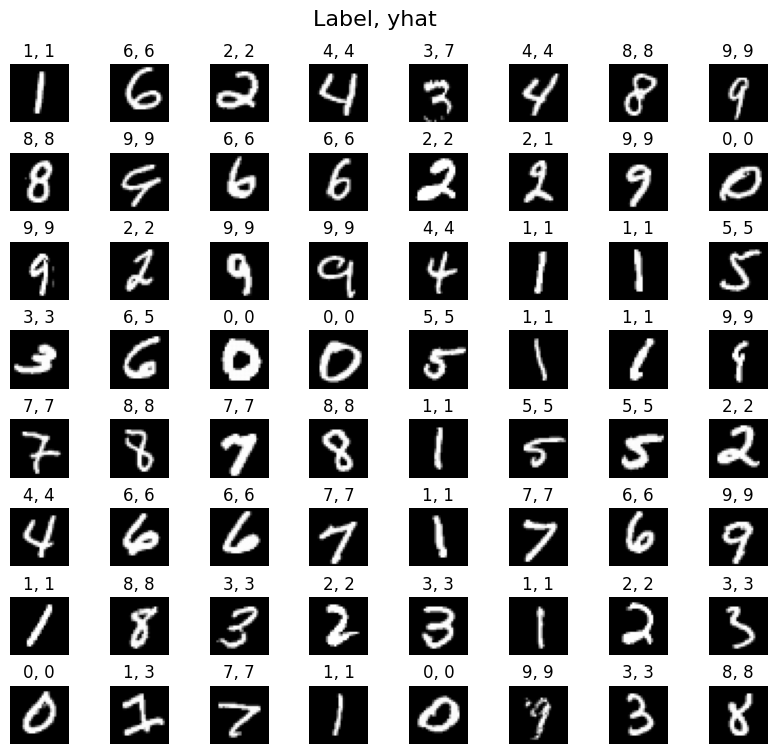

In [84]:
m, n, _= x_test.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92])

for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(m)
    X_random = x_test[random_index]
    ax.imshow(X_random, cmap='gray')
    yhat = np.argmax(model.predict(x_test[random_index].reshape(1, 28, 28)))
    ax.set_title(f"{y_test[random_index]}, {yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()

In [85]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [86]:
y_pred = [np.argmax(digit) for digit in predictions]

In [87]:
conf_mat = confusion_matrix(y_test, y_pred)

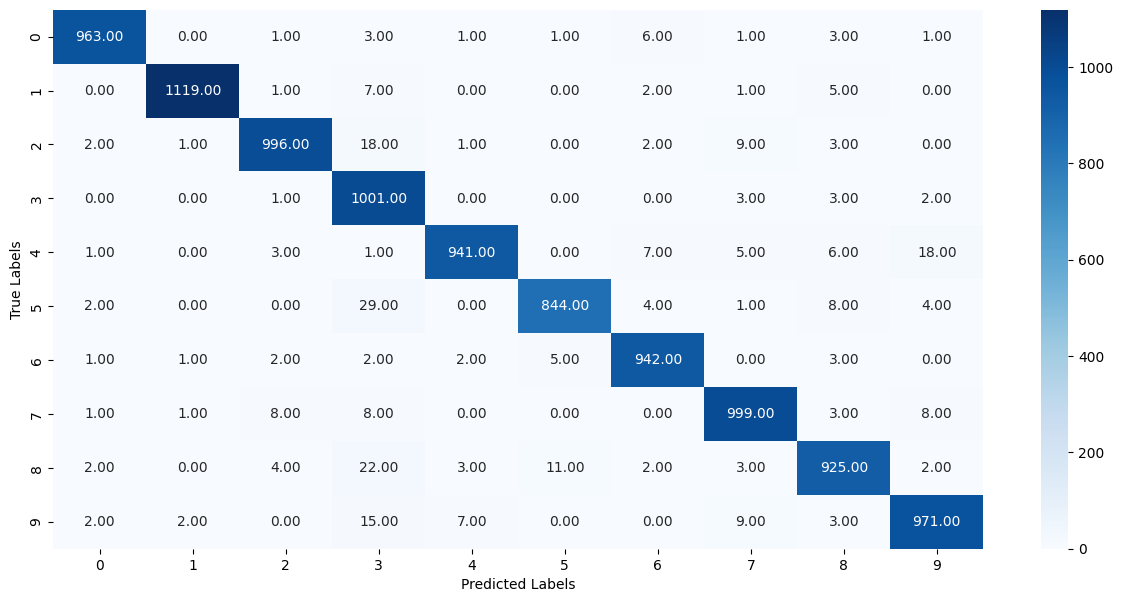

In [88]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='.2f', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
This digit is probably a 5


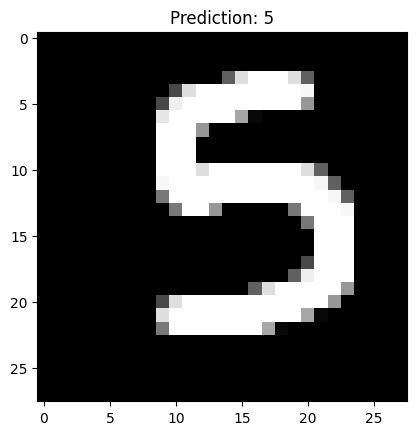

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
This digit is probably a 3


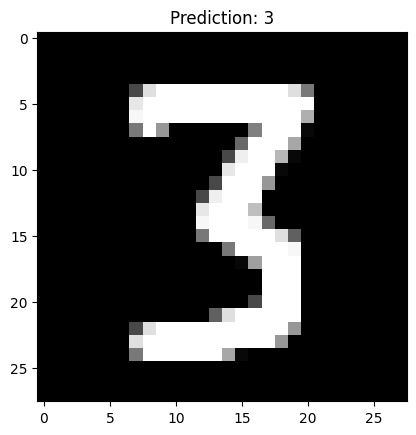

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
This digit is probably a 3


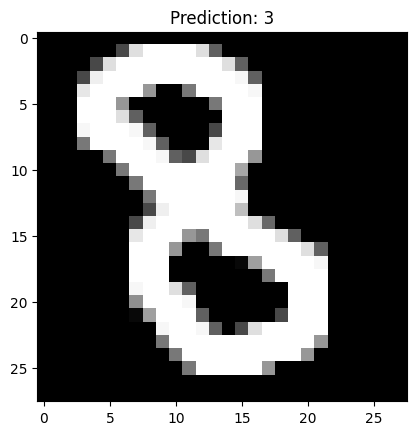

In [89]:
for i in range(1, 4):
    path = f"image{i}.png"
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = np.invert(np.array([img]))
        yhat = np.argmax(model.predict(img))
        print(f"This digit is probably a {yhat}")
        plt.imshow(img[0], cmap='gray')
        plt.title(f"Prediction: {yhat}")
        plt.show()
    
    except Exception as e:
        print(f"Error with {path}: {e}")

# Model 2 :

In [90]:
model2 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax'),
])

c:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [91]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [92]:

model2.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9295 - loss: 0.2418
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9694 - loss: 0.1016
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9797 - loss: 0.0675
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9853 - loss: 0.0475
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9882 - loss: 0.0378


In [93]:
test_loss, test_accuracy = model2.evaluate(x_test, y_test)
print(f"Accuracy of the neural network on the {x_test.shape[0]} test images: {test_accuracy * 100:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0839
Accuracy of the neural network on the 10000 test images: 97.48


In [94]:
predictions = model2.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [95]:
y_pred = [np.argmax(digit) for digit in predictions]

In [96]:
conf_mat = confusion_matrix(y_test, y_pred)

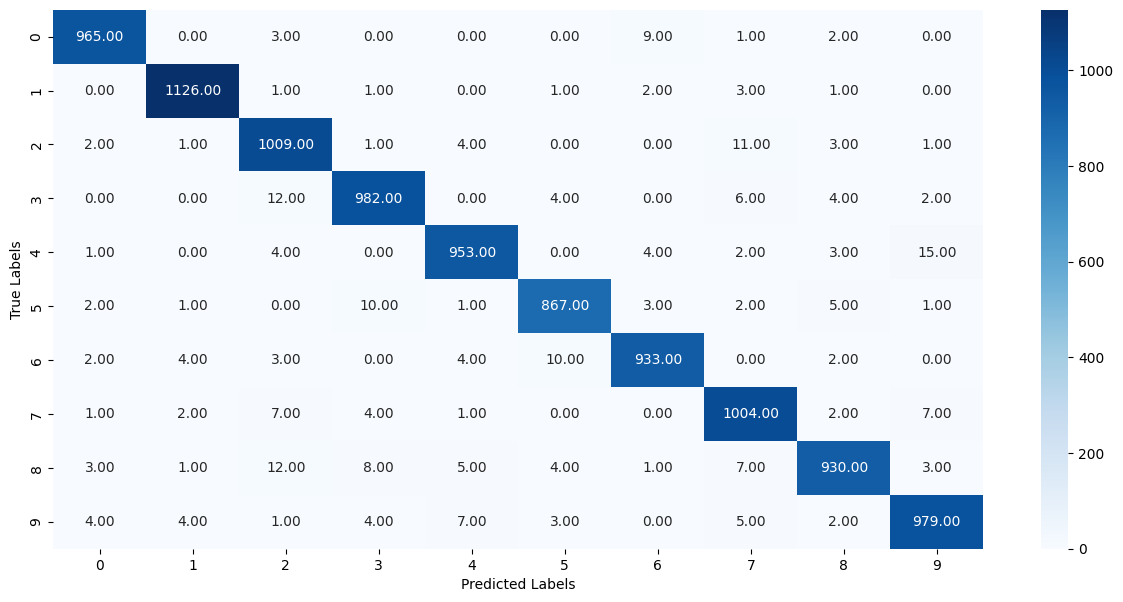

In [97]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='.2f', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
This digit is probably a 5


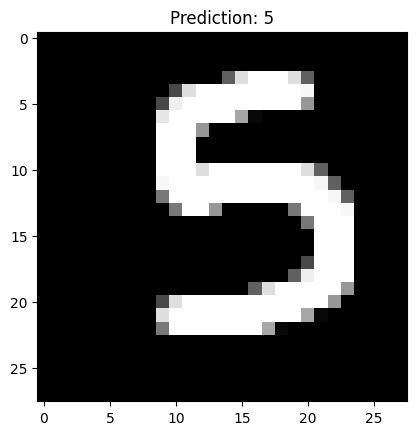

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
This digit is probably a 3


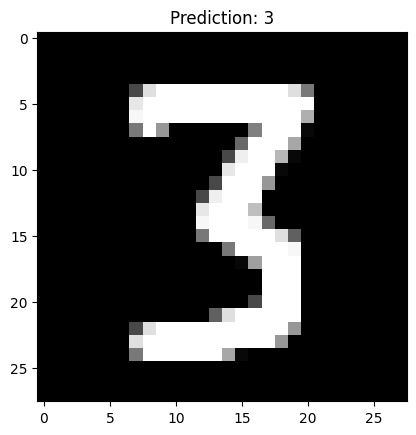

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
This digit is probably a 8


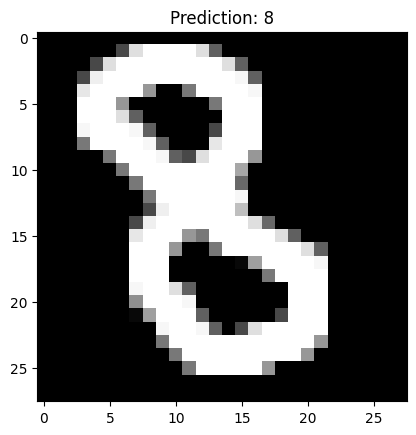

In [98]:
for i in range(1, 4):
    path = f"image{i}.png"
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = np.invert(np.array([img]))
        yhat = np.argmax(model2.predict(img))
        print(f"This digit is probably a {yhat}")
        plt.imshow(img[0], cmap='gray')
        plt.title(f"Prediction: {yhat}")
        plt.show()
    
    except Exception as e:
        print(f"Error with {path}: {e}")

# Model 3 :

In [11]:
model3 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax'),
])

In [12]:
model3.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [13]:
num_epochs = 10
batch_size = 256

history = model3.fit(x_train, y_train, 
                    epochs=num_epochs, 
                    batch_size=batch_size, 
                    validation_data=(x_test, y_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9072 - loss: 0.3141 - val_accuracy: 0.9632 - val_loss: 0.1195
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9641 - loss: 0.1197 - val_accuracy: 0.9736 - val_loss: 0.0844
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9758 - loss: 0.0802 - val_accuracy: 0.9748 - val_loss: 0.0795
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9804 - loss: 0.0623 - val_accuracy: 0.9771 - val_loss: 0.0712
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9844 - loss: 0.0506 - val_accuracy: 0.9795 - val_loss: 0.0669
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9864 - loss: 0.0428 - val_accuracy: 0.9803 - val_loss: 0.0650
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9883 - loss: 0.0357 - val_accuracy: 0.9815 - val_loss: 0.0633
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9896 - loss: 0.0313 - val_acc

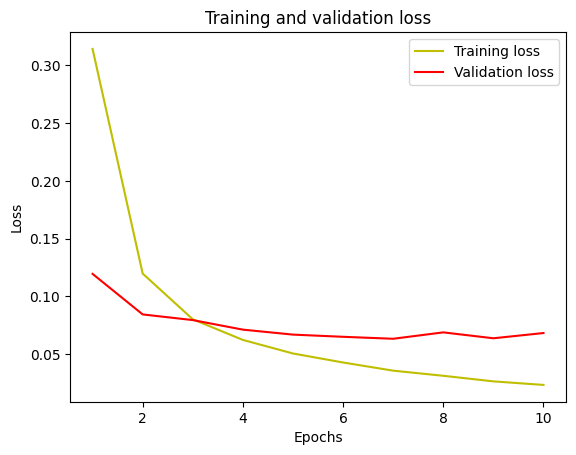

In [14]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

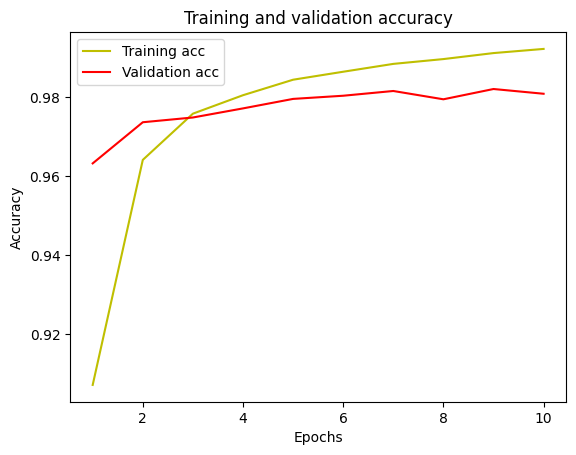

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [16]:
test_loss, test_accuracy = model3.evaluate(x_test, y_test)
print(f"Accuracy of the neural network on the {x_test.shape[0]} test images: {test_accuracy * 100:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - loss: 0.0683
Accuracy of the neural network on the 10000 test images: 98.08


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
This digit is probably a 5


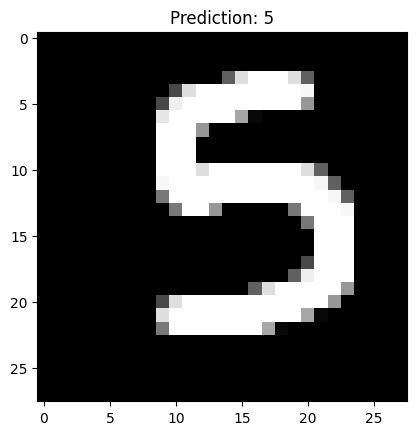

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
This digit is probably a 3


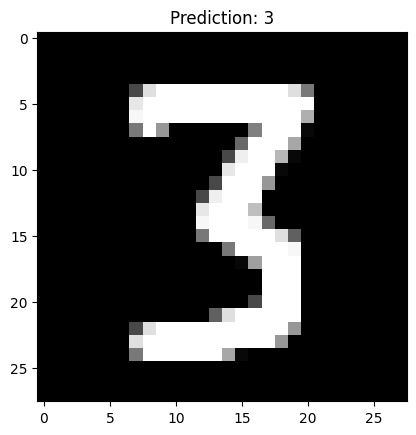

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
This digit is probably a 3


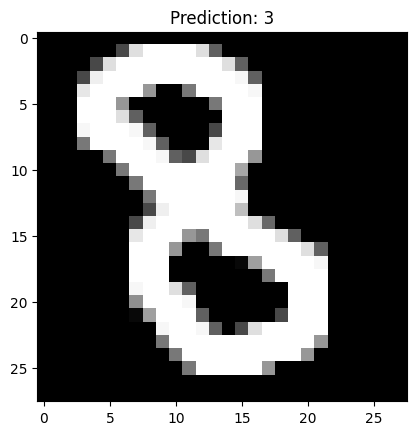

In [17]:
for i in range(1, 4):
    path = f"image{i}.png"
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = np.invert(np.array([img]))
        yhat = np.argmax(model3.predict(img))
        print(f"This digit is probably a {yhat}")
        plt.imshow(img[0], cmap='gray')
        plt.title(f"Prediction: {yhat}")
        plt.show()
    
    except Exception as e:
        print(f"Error with {path}: {e}")

In [18]:
model3.save("handwritten_clf.h5")